## Basic inititalization of the dataset and the model

In [1]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 8.4 MB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 9.7 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.1 MB 9.9 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 7.8 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 6.8 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.5 MB/s  0:00:01
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 6.7 MB/s eta 0:00:01
   ------------- ----------------------

In [2]:
# import the libraries 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import numpy as np

In [3]:
# load the dataset
data=load_iris()
x=data.data[:,:2]
y=data.target

In [5]:
#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
#scale the features
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

## create a decision boundary function

In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x, y)

def plot_Boundary(model,x,y,title):
    h=0.02
    x_min,x_max=x[:,0].min() - 1,x[:,0].max() + 1
    y_min,y_max=x[:,1].min() - 1,x[:,1].max() + 1

    
    # Meshgrid banana
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Model se prediction lena
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.4)
    # Actual data points plot karna
    plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k')

    # plot support vectores
    plt.scatter(model.support_vectors_[:,0],model.support_vectors_[:,1],edgecolors='black')

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

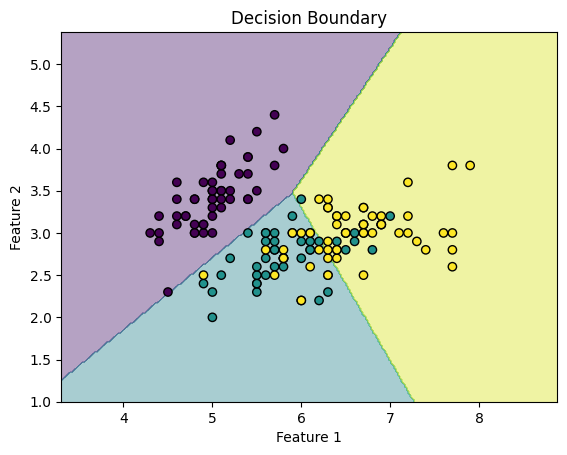

In [23]:
plot_Boundary(model, x, y, "Decision Boundary")

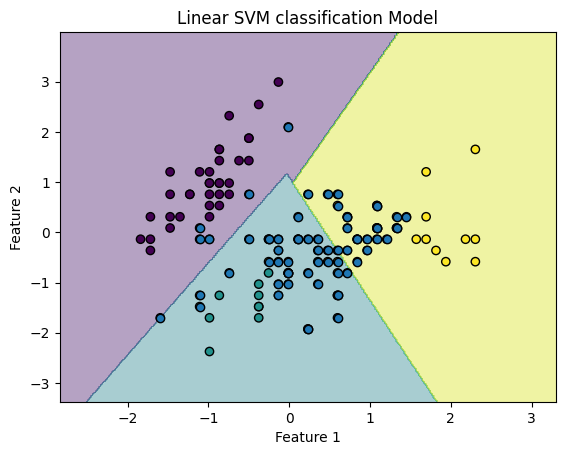

In [26]:
# Linear Kernel SVM
linear_svm = SVC(kernel='linear')
linear_svm.fit(x_train,y_train)

plot_Boundary(linear_svm, x_train, y_train, "Linear SVM classification Model")

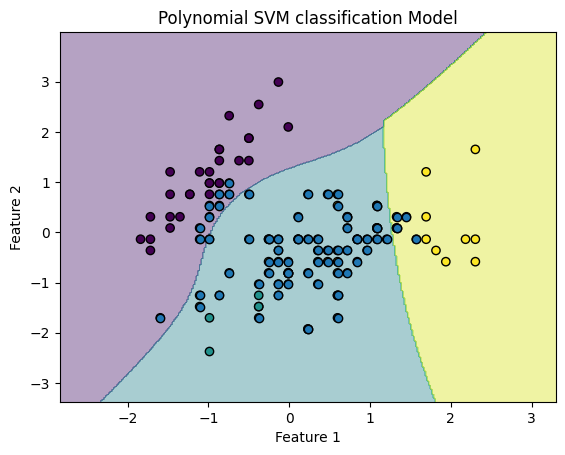

In [27]:
# Polynomial Kernel SVM
poly_svm = SVC(kernel='poly')
poly_svm.fit(x_train,y_train)

plot_Boundary(poly_svm, x_train, y_train, "Polynomial SVM classification Model")

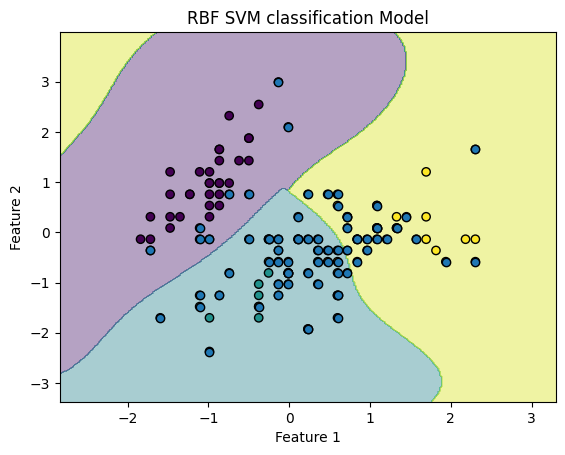

In [31]:
# RBF SVM Model
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(x_train, y_train)

plot_Boundary(rbf_svm, x_train, y_train, "RBF SVM classification Model")

In [32]:
# Install (Colab / Jupyter me ek baar run karo)
# !pip install mlxtend

# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from mlxtend.plotting import plot_decision_regions


In [33]:

X, y = datasets.make_moons(n_samples=200, noise=0.2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


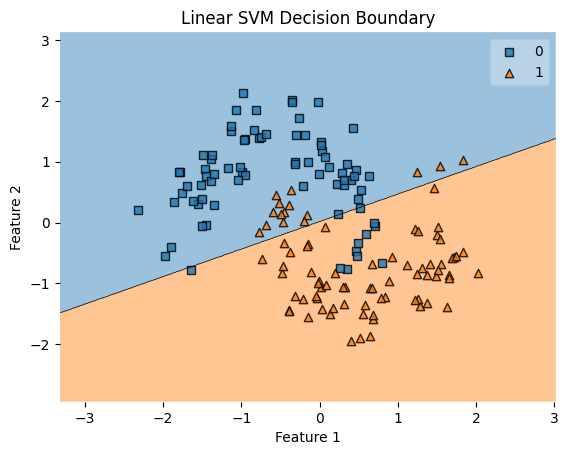

In [37]:
# Linear Kernel SVM

linear_svm = SVC(kernel='linear')
linear_svm.fit(x_train, y_train)

plt.figure()
plot_decision_regions(x_train, y_train, clf=linear_svm)
plt.title("Linear SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


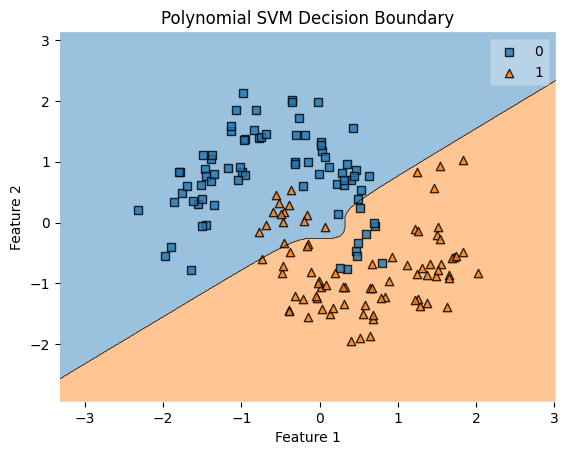

In [38]:
# Polynomial Kernel SVM

poly_svm = SVC(kernel='poly', degree=3)
poly_svm.fit(x_train, y_train)

plt.figure()
plot_decision_regions(x_train, y_train, clf=poly_svm)
plt.title("Polynomial SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

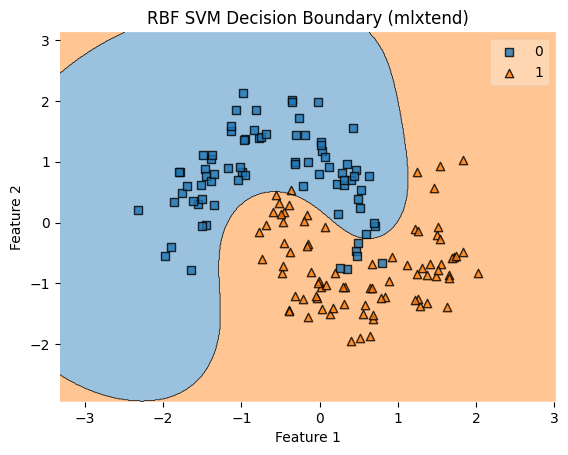

In [39]:
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(x_train, y_train)
plot_decision_regions(x_train, y_train, clf=rbf_svm)

plt.title("RBF SVM Decision Boundary (mlxtend)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()